# Comparing DBSCAN and HDBSCAN clustering 

## Objectives

After completing this lab, you will be able to:

* Use scikit-learn to implement DBSCAN and HDBSCAN clustering models to real data
* Compare the performances of the two models 



## Introduction
In this lab, you'll create two clustering models using data curated by StatCan containing the names, types, and locations of
cultural and art facilities across Canada.
We'll focus on the museum locations provided across Canada.

#### Data source: The Open Database of Cultural and Art Facilities (ODCAF)

A collection of open data containing the names, types, and locations of cultural and art facilities across Canada. 
It is released under the Open Government License - Canada.
The different types of facilities are labeled under 'ODCAF_Facility_Type'.

#### Landing page:
https://www.statcan.gc.ca/en/lode/databases/odcaf

#### link to zip file:
https://www150.statcan.gc.ca/n1/en/pub/21-26-0001/2020001/ODCAF_V1.0.zip?st=brOCT3Ry


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import requests
import geopandas as gpd  # pandas dataframe-like geodataframes for geographical data
import contextily as ctx  # used for obtianing a basemap of Canada
from shapely.geometry import Point


In [3]:
def download (url, fileName):
    response = requests.get(url)
    if(response.status_code == 200):
        with open(fileName, "wb") as f:
            f.write(response.content)

In [5]:
file_path =  'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
file_name = 'ODCAF-v1-0.csv'

In [5]:
download(file_path,file_name)

In [6]:
df = pd.read_csv(file_name, encoding='ISO-8859-1')
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


## Data Preprocessing


In [7]:
df.isnull().sum()

Index                    0
Facility_Name            0
Source_Facility_Type     0
ODCAF_Facility_Type      0
Provider                 0
Unit                     0
Street_No                0
Street_Name              0
Postal_Code              0
City                     0
Prov_Terr                0
Source_Format_Address    0
CSD_Name                 0
CSDUID                   0
PRUID                    0
Latitude                 0
Longitude                0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Index                  7972 non-null   int64
 1   Facility_Name          7972 non-null   str  
 2   Source_Facility_Type   7972 non-null   str  
 3   ODCAF_Facility_Type    7972 non-null   str  
 4   Provider               7972 non-null   str  
 5   Unit                   7972 non-null   str  
 6   Street_No              7972 non-null   str  
 7   Street_Name            7972 non-null   str  
 8   Postal_Code            7972 non-null   str  
 9   City                   7972 non-null   str  
 10  Prov_Terr              7972 non-null   str  
 11  Source_Format_Address  7972 non-null   str  
 12  CSD_Name               7972 non-null   str  
 13  CSDUID                 7972 non-null   str  
 14  PRUID                  7972 non-null   str  
 15  Latitude               7972 non-null   str  
 16 

In [12]:
# Display ODCAF_Facility_Type and their counts

df['ODCAF_Facility_Type'].value_counts()

ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64

In [17]:
#Filter the data to only include museums.
df_mus = df[df['ODCAF_Facility_Type'] == 'museum']
df_mus 

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
8,10,12 Service Battalion Museum,military museum or fort,museum,canadian museums association,..,5500,no 4 rd,V6X 3L5,richmond,bc,5500 no. 4 rd the sherman armoury richmond bri...,Richmond,5915015,59,49.1763542,-123.112783
13,15,15th Field Artillery Regiment Museum And Archives,museum/gallery,museum,vancouver,..,2025,11th av w,V6J 2C7,vancouver,bc,2025 w 11th av vancouver bc v6j 2c7,Vancouver,5915022,59,49.261938,-123.151123
15,18,17 Wing Heritage Collection,aeronautics and space museum transportation mu...,museum,canadian museums association,..,..,..,R3J 3Y5,winnipeg,mb,air heritage park air force way winnipeg manit...,Winnipeg,4611040,46,49.88955855,-97.23574396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7940,9765,York Region District School Board Museum & Arc...,library and/or archives community/regional museum,museum,canadian museums association,..,21,renfrew dr,L3R 8H3,markham,on,21 renfrew dr markham ontario l3r 8h3 canada,Markham,3519036,35,43.857692,-79.3619396
7954,9779,Youthlink Calgary-The Calgary Police Interpret...,community/regional museum exhibition or cultur...,museum,canadian museums association,..,5111,47th street ne,T3J 3R2,calgary,ab,5111-47th street ne lc594 calgary alberta t3j ...,Calgary,4806016,48,..,..
7958,9783,Yukon Beringia Interpretive Centre,human history-archaelogy-anthropology or ethno...,museum,canadian museums association,..,1423,alaska hwy,Y1A 2C6,whitehorse,yt,kilometre 1423 (mile 886) alaska hwy po box 27...,Whitehorse,6001009,60,..,..
7968,9797,Craigdarroch Castle,museums and galleries,museum,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.42241956,-123.3435527


Select only the Latitude and Longitude features as inputs to our clustering problem.
Also, display information about the coordinates like counts and data types.

In [35]:
df_data = df_mus.filter(['Latitude', 'Longitude'], axis=1)
df_data

,Latitude,Longitude
1,55.2645508,-127.6428124
2,45.963283,-66.6419017
8,49.1763542,-123.112783
13,49.261938,-123.151123
15,49.88955855,-97.23574396
...,...,...
7940,43.857692,-79.3619396
7954,..,..
7958,..,..
7968,48.42241956,-123.3435527


In [27]:
df_data.info()

<class 'pandas.DataFrame'>
Index: 1938 entries, 1 to 7969
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Latitude   1938 non-null   str  
 1   Longitude  1938 non-null   str  
dtypes: str(2)
memory usage: 45.4 KB


In [ ]:
# Remove observations with no coordinates 
df_data = df_data[df_data['Latitude'] != '..']

df_data

,Latitude,Longitude
1,55.2645508,-127.6428124
2,45.963283,-66.6419017
8,49.1763542,-123.112783
13,49.261938,-123.151123
15,49.88955855,-97.23574396
...,...,...
7934,43.18308983,-79.2245641
7936,43.6900216,-79.476208
7940,43.857692,-79.3619396
7968,48.42241956,-123.3435527


In [45]:
df_data = df_data[df_data['Longitude'] != '..']
df_data.value_counts()

Latitude     Longitude   
51.01423945  -114.1162943    6
45.71061766  -63.2859451     3
48.369878    -53.359843      3
49.89093415  -97.153417      2
49.0960503   -99.3400468     2
                            ..
43.18308983  -79.2245641     1
43.6900216   -79.476208      1
43.857692    -79.3619396     1
48.42241956  -123.3435527    1
48.4260053   -123.3691883    1
Name: count, Length: 1583, dtype: int64

In [47]:
# Remove rows where Latitude or Longitude is ".."
df_data = df_data[(df_data['Latitude'] != "..") & (df_data['Longitude'] != "..")]

# Convert columns into floats
df_data[['Latitude', 'Longitude']] = df_data[['Latitude', 'Longitude']].astype('float64')

In [48]:
df_data.info()

<class 'pandas.DataFrame'>
Index: 1607 entries, 1 to 7969
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   1607 non-null   float64
 1   Longitude  1607 non-null   float64
dtypes: float64(2)
memory usage: 37.7 KB


In [49]:
coordinates = df_data.copy()
coordinates

,Latitude,Longitude
1,55.264551,-127.642812
2,45.963283,-66.641902
8,49.176354,-123.112783
13,49.261938,-123.151123
15,49.889559,-97.235744
...,...,...
7934,43.183090,-79.224564
7936,43.690022,-79.476208
7940,43.857692,-79.361940
7968,48.422420,-123.343553


In [50]:
coordinates['Latitude'] = 2 * coordinates['Latitude']


### Apply DBSCAN with Euclidean distance to the scaled coordinates
In this case, reasonable neighbourhood parameters are already chosen for you. Feel free to experiment.


In [51]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(metric='euclidean', min_samples=3, eps=1.0)
# train the model

dbscan.fit(coordinates)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1.0
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",3
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [61]:
df_data['Cluster'] = dbscan.fit_predict(coordinates) 

In [62]:
df_data['Cluster'].value_counts()

Cluster
 4     701
 2     192
 1     181
 7     134
 3      94
-1      79
 6      30
 10     27
 8      21
 11     15
 15     13
 20     11
 16     10
 19      9
 27      8
 12      7
 5       6
 14      6
 18      6
 24      6
 26      6
 28      6
 9       4
 13      4
 22      4
 0       3
 17      3
 21      3
 23      3
 25      3
 29      3
 31      3
 30      3
 32      3
Name: count, dtype: int64

In [63]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):  # Check if it's a TIFF file
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

Downloaded and extracted: Canada.tif


In [66]:
# Write a function that plots clustered locations and overlays them on a basemap.

def plot_clustered_locations(df,  title='Museums Clustered by Proximity'):
    """
    Plots clustered locations and overlays on a basemap.
    
    Parameters:
    - df: DataFrame containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    """
    
    # Load the coordinates intto a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")
    
    # Reproject to Web Mercator to align with basemap 
    gdf = gdf.to_crs(epsg=3857)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Separate non-noise, or clustered points from noise, or unclustered points
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]
    
    # Plot noise points 
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
    
    # Plot clustered points, colured by 'Cluster' number
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)
    
    # Add basemap of  Canada
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)
    
    # Format plot
    plt.title(title, )
    plt.legend()
    plt.xlabel('Longitude', )
    plt.ylabel('Latitude', )
    
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    
    # Show the plot
    plt.show()

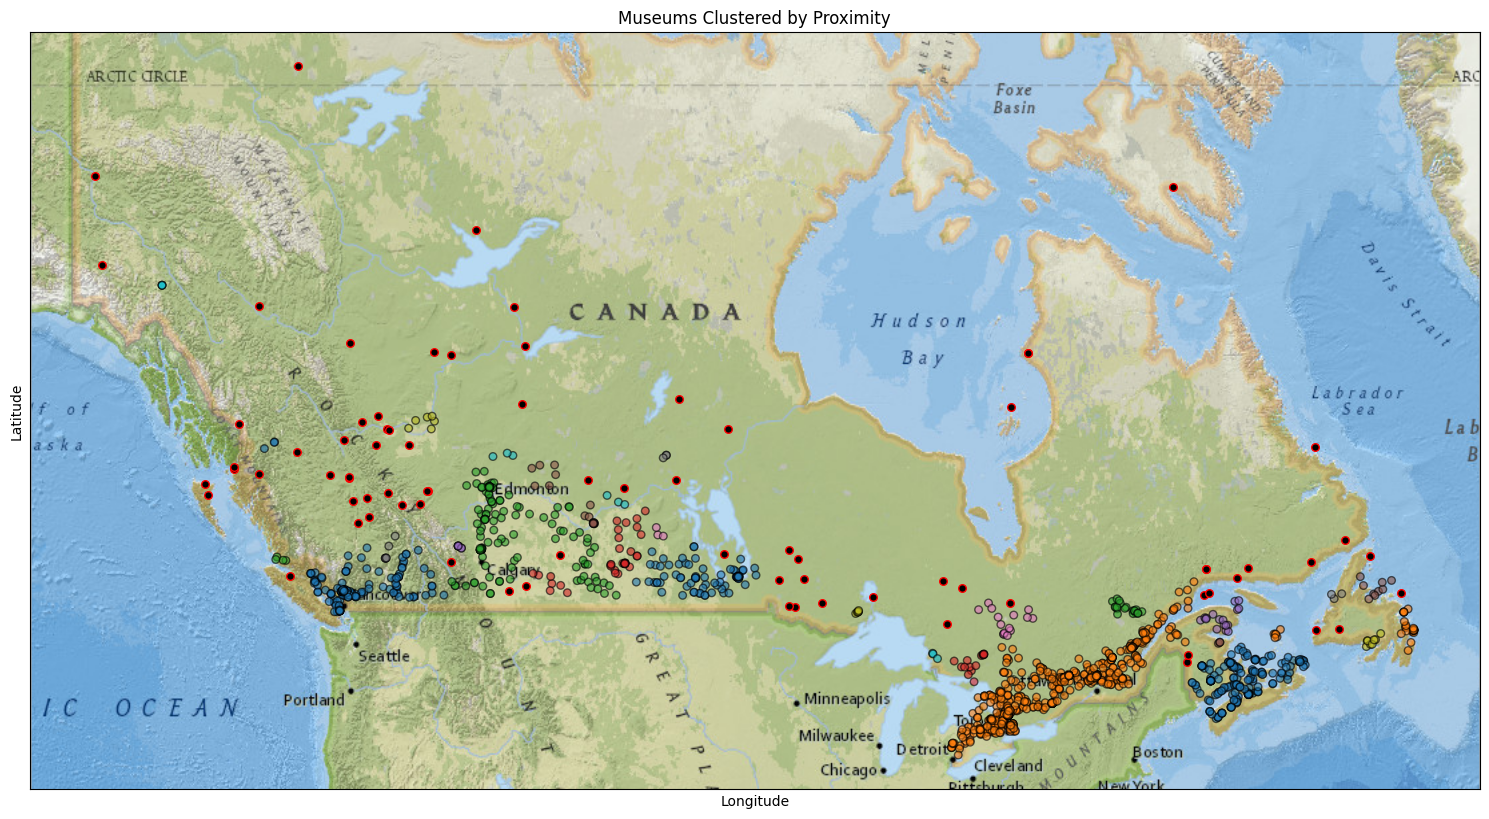

In [65]:
plot_clustered_locations(df_data, title='Museums Clustered by Proximity')